In [72]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/EstructuraDatos_2026_02
!pip install -q -r requirements.txt

import sys
sys.path.append('/content/drive/MyDrive/EstructuraDatos_2026_02')

Mounted at /content/drive
/content/drive/MyDrive/EstructuraDatos_2026_02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 67.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.1/915.1 kB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 87.3 MB/s eta 0:00:00


# Laboratorio 1 — CH03: Análisis de Algoritmos

Ejercicios de Goodrich, Tamassia & Goldwasser.

## Ejercicio 1 — C-3.50

Sea $p(x)$ un polinomio de grado $n$, es decir,

$$p(x) = \sum_{i=0}^{n} a_i x^i$$

**(a)** Describa un algoritmo simple de tiempo $O(n^2)$ para calcular $p(x)$.

**(b)** Mejore el algoritmo anterior calculando $x^i$ de una forma más eficiente.

**(c)** Ahora considere la siguiente reescritura de $p(x)$:

$$p(x) = a_0 + x\big(a_1 + x\big(a_2 + x\big(a_3 + \cdots + x(a_{n-1} + x a_n)\cdots\big)\big)\big)$$

conocida como el **método de Horner**. Usando la notación big-Oh, caracterice el número de operaciones aritméticas que ejecuta este método.

### (a) Algoritmo $O(n^2)$

In [ ]:
def p_cuadratico(a, x):
    suma = 0
    #grado = len(a)-1
    xi = 1
    for i in range(len(a)):
        suma += a[i]*xi
        xi *= x

    return suma

In [ ]:
p_cuadratico([1,2,3],2)


17

### (b) Algoritmo mejorado

In [ ]:
def p_mejorado(a, x):
    pass

### (c) Método de Horner

In [ ]:
def horner(a, x):
    suma = a[-2] + x*a[-1]
    a1 = a[:-2]
    for i in a1[::-1]:
        suma = i+ x*suma
    return suma

In [ ]:
horner([1,2,3],2)

17

### Verificación de resultados

Los tres algoritmos deben dar el mismo resultado para $p(x) = 3 + 2x + 5x^2 - x^3 + 4x^4$ evaluado en $x=2$.

In [ ]:
# a = [a0, a1, a2, a3, a4] -> p(x) = 3 + 2x + 5x^2 - x^3 + 4x^4
a = [3, 2, 5, -1, 4]
x = 2

print("p_cuadratico:", p_cuadratico(a, x))
print("p_mejorado:  ", p_mejorado(a, x))
print("horner:      ", horner(a, x))

## Ejercicio 2 — División sintética

La **división sintética** permite evaluar un polinomio $p(x) = \sum_{i=0}^{n} a_i x^i$ en un valor $x = r$, dividiendo $p(x)$ entre $(x - r)$: el residuo de esa división es exactamente $p(r)$.

Programe una función `division_sintetica(a, r)` que implemente este método para evaluar el polinomio en $r$.

**Pregunta:** ¿es este método igual al método de Horner de la parte (c)? Justifique su respuesta comparando ambos algoritmos.

In [7]:
def division_sintetica(a, r):
    resultado = a[-1]
    for i in range(len(a)-2,-1,-1):
      resultado = a[i] + r*resultado
    return resultado

In [8]:
division_sintetica([1,2,3],2)

17

### Verificación

`division_sintetica` debe dar el mismo resultado que `horner` para el mismo polinomio y el mismo valor de evaluación.

In [ ]:
print("horner:              ", horner(a, x))
print("division_sintetica:  ", division_sintetica(a, x))

## Ejercicio 3 — Comparación de algoritmos

El número de operaciones ejecutadas por los algoritmos A y B es $n^2 + n$ y $\dfrac{n^3}{200}$, respectivamente.

Determine $n_0$ tal que A es mejor que B para $n \geq n_0$.

Haga una gráfica (similar a las del notebook `ch03_teoria.ipynb`) que muestre ambas funciones. Ajustar la gráfica como en el cuaderno de teoría.

In [16]:
# Escriba aquí su análisis y la gráfica con matplotlib

# n^2 + n < n^3/200
# 200n^2 + 200n < n^3
# n^3 - 200n^2 - 200n > 0
# n(n^2 - 200n - 200) > 0
for n in range(1, 500):
    if n**2 + n < n**3/200:
        print(n)
        break

201


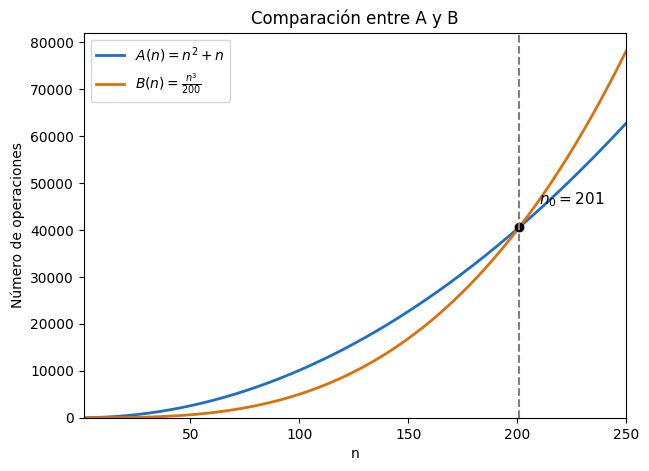

In [14]:
import numpy as np
import matplotlib.pyplot as plt

n = np.linspace(1, 250, 500)

fA = n**2 + n
fB = n**3/200

n0 = 201
yA_n0 = n0**2 + n0

fig1, ax = plt.subplots(figsize=(7,5))

ax.plot(n, fA, color="#1B6FC9", linewidth=2,
        label=r"$A(n)=n^2+n$")

ax.plot(n, fB, color="#D9720C", linewidth=2,
        label=r"$B(n)=\frac{n^3}{200}$")

# Punto n0
ax.plot(n0, yA_n0, "o", color="black")
ax.axvline(n0, linestyle="--", color="gray")

ax.annotate(
    f"$n_0={n0}$",
    xy=(n0, yA_n0),
    xytext=(210, yA_n0+5000),
    fontsize=11
)

ax.set_xlabel("n")
ax.set_ylabel("Número de operaciones")
ax.set_title("Comparación entre A y B")

ax.legend()

ax.set_xlim(1,250)
ax.set_ylim(0, max(fB)*1.05)

plt.show()

## Ejercicio 4 — Three-way set disjointness

Suponiendo que es posible ordenar $n$ números en tiempo $O(n\log n)$, demuestre que es posible resolver el problema de disyunción de tres conjuntos (**three-way set disjointness**) en tiempo $O(n\log n)$.

Programe una función `disjointness_nlogn(A, B, C)` que reciba tres secuencias de tamaño $n$ y retorne `True` si no existe ningún elemento común a las tres, usando ordenamiento en vez de los tres ciclos anidados de la versión $O(n^3)$.

In [18]:
def disjointness_nlogn(A, B, C):
    i = j = k = 0
    while i<len(A) and j<len(B) and k<len(C):
        a = A[i]
        b = B[j]
        c = C[k]

        if a == b == c:
            return False

        if a<=b and a<=c:
            i += 1
        elif b<=a and b<=c:
            j += 1
        else:
            k += 1

    return True

In [21]:
disjointness_nlogn(list(range(1,1000)), list(range(1,2000)), list(range(1,3000)))

False

## Ejercicio 5 — R-3.28

Para cada función $f(n)$ y tiempo $t$ en la siguiente tabla, determine el tamaño más grande $n$ de un problema $P$ que puede resolverse en tiempo $t$ si el algoritmo que resuelve $P$ tarda $f(n)$ microsegundos (una entrada ya está completa).

| $f(n)$ | 1 Segundo | 1 Hora | 1 Mes | 1 Siglo |
|---|---|---|---|---|
| $\log n$ | $\approx 10^{300000}$ | | | |
| $n$ | | | | |
| $n\log n$ | | | | |
| $n^2$ | | | | |
| $2^n$ | | | | |

Complete la tabla. Puede apoyarse en una celda de código para hacer los cálculos.

In [ ]:
# Escriba aquí sus cálculos


## Ejercicio 6 — Valor más frecuente en un rango acotado

Una secuencia $S$ contiene $n$ enteros tomados del intervalo $[0, 4n]$, con repeticiones permitidas.

Describa un algoritmo eficiente para determinar un valor entero $k$ que ocurre con mayor frecuencia en $S$. ¿Cuál es el tiempo de ejecución de su algoritmo?

In [51]:
def valor_mas_frecuente(S, n):
    frecuencia = [0] * (4*n+1)

    for numero in S:
      frecuencia[numero] += 1

    mayor_frecuencia = frecuencia[0]
    valor = 0
    for i in range(1, len(frecuencia)):
      if frecuencia[i] > mayor_frecuencia:
        mayor_frecuencia = frecuencia[i]
        valor = i

    return valor

In [52]:
valor_mas_frecuente([1,2,3,3,4], 4)

3

## Ejercicio 7 — Búsqueda secuencial

Dada una lista $L$ de $n$ elementos (sin ordenar) y un valor $x$, programe una función `busqueda_secuencial(L, x)` que retorne `True` si $x$ se encuentra en $L$ y `False` en caso contrario, recorriendo la lista elemento por elemento.

Analice el mejor y el peor caso de este algoritmo usando notación big-Oh.

In [57]:
def busqueda_secuencial(L, x):
    for i in L:
      if i == x:
        return True
      return False

# si x está de primero, se demora 0(1)
# si no, entonces: está de ultimo o no está:
# entonces se demora O(n), porque tiene que recorrer toda la lista de n elementos

In [58]:
busqueda_secuencial([1,2,3],4)

False

## Ejercicio 8 — Búsqueda binaria

Dada una lista $L$ **ordenada** de $n$ elementos y un valor $x$, programe una función `busqueda_binaria(L, x)` que retorne `True` si $x$ se encuentra en $L$ y `False` en caso contrario, descartando en cada paso la mitad de los elementos restantes.

¿Cuál es el tiempo de ejecución de este algoritmo, usando notación big-Oh? Compárelo con el de la búsqueda secuencial del ejercicio anterior.

In [68]:
def busqueda_binaria(L, x):
    inicio = 0
    final = len(L)-1
    while inicio <= final:
      mitad = (inicio + final)//2
      if x == L[mitad]:
        return True
      elif x < L[mitad]:
        final = mitad-1
      else:
        inicio = mitad+1
    return False

In [69]:
busqueda_binaria([1,2,3,4],5)

False

In [71]:
!git add student_work/
!git commit -m "Laboratorio 1"
!git push

fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git


In [74]:
from google.colab import userdata

usuario_github = "AdrianValencia008"
repo = "EstructuraDatos_2026_02"
token = userdata.get('GITHUB_TOKEN').strip()

%cd /content/drive/MyDrive/{repo}
!git config --global user.email "adrian.valencia1@est.uexternado.edu.co"
!git config --global user.name "AdrianValencia008"
!git add student_work/
!git commit -m "Ejercicios - Laboratorio"
!git push https://{token}@github.com/{usuario_github}/{repo}.git main

/content/drive/MyDrive/EstructuraDatos_2026_02
[main caa0c67] Ejercicios - Laboratorio
 1 file changed, 1 insertion(+)
 create mode 100644 student_work/laboratorio1.ipynb
Enumerating objects: 6, done.
Counting objects: 100% (6/6), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 48.30 KiB | 2.68 MiB/s, done.
Total 4 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/AdrianValencia008/EstructuraDatos_2026_02.git
   16f3878..caa0c67  main -> main
